# Анализ магазина спортивных товаров

### Цель: c помощью данных о покупках клиентов и их социально-демографических признаках проанализировать эффективность уже проведённых ранее маркетинговых кампаний и выявить факторы, способные повысить продажи.


### Краткие выводы: 
1.	Маркетинговая кампания не принесла существенного роста покупок со стороны клиентов
2.	Кластеризация выявила незначительную часть покупателей, совершающих дорогие покупки.
3.	Основным фактором влияния оказалась на склонность клиента города 1188 к покупке оказалась стоимость товара.


### Загружаем необходимые библиотеки, загружаем данные

In [1]:
import pandas as pd
import numpy as np
import re
import sqlite3

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, train_test_split , cross_val_score

from kmodes.kprototypes import KPrototypes
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score

from sklearn.metrics import mean_squared_error, mean_absolute_error,classification_report, roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline

from scipy.stats import levene, shapiro, ttest_ind

import matplotlib.pyplot as plt

from IPython.display import display, Markdown

In [2]:
#Импортируем данные из базы
dbfile = 'shop_database.db'
conn = sqlite3.connect(dbfile)
cursor = conn.cursor()

In [3]:
#Сформируем датафрейм из таблиц персональные данные, персональные коэффициенты, данные о покупках, при условии, что код страны = 32
df = pd.read_sql_query("SELECT pd.id, pd.gender, pd.education, pd.city, pd.country, \
                                pr.product, pr.colour, pr.cost, pr.product_sex, pr.base_sale, pr.dt, \
                                pdc.lbt_coef, pdc.ac_coef, pdc.sm_coef, pdc.personal_coef FROM personal_data AS pd \
                        JOIN (SELECT id, product, colour, cost, product_sex, base_sale, dt FROM purchases) AS pr ON pd.id = pr.id \
                        JOIN (SELECT id, lbt_coef, ac_coef, sm_coef, personal_coef FROM personal_data_coeffs) AS pdc ON pd.id = pdc.id \
                        WHERE pd.country = 32", conn)
conn.close()

In [3]:
# Данные о покупках
df_purchases = pd.read_sql_query("SELECT id, product, colour, cost, product_sex, base_sale, dt FROM purchases", conn)

# Данные клиeнтов
df_personal_data = pd.read_sql_query("SELECT id, gender, age, education, city, country FROM personal_data WHERE country = 32", conn)

#Данные о персональных коэффициентах
df_coeff = pd.read_sql_query("SELECT id, personal_coef FROM personal_data_coeffs", conn)

conn.close()

In [4]:
df_purchases.head()

,id,product,colour,cost,product_sex,base_sale,dt
0,0,"Велосипед горный женский Stern Mira 2.0 26""",белый/синий,13599,0.0,1,7
1,0,Стол Outventure,зелёный,1499,NaN,0,37
2,0,Набор Outventure: стол + 4 стула,бежевый,4799,NaN,0,37
3,3,Бутсы мужские GSD Astro,белый,1599,1.0,0,13
4,3,Мяч футбольный PUMA TEAMFINAL 21.2 FIFA QUALIT...,мультицвет,7199,NaN,0,27


In [5]:
df_personal_data.head()

,id,gender,age,education,city,country
0,0,0,36,среднее,1201,32
1,4,0,35,среднее,1134,32
2,6,1,52,среднее,1188,32
3,7,0,37,среднее,1198,32
4,9,0,48,среднее,1134,32


In [6]:
df_coeff.head()

,id,personal_coef
0,0,0.5072
1,3,0.4304
2,4,0.5072
3,6,0.4304
4,7,0.5072


###### Графическое представление информации о данных клиентов

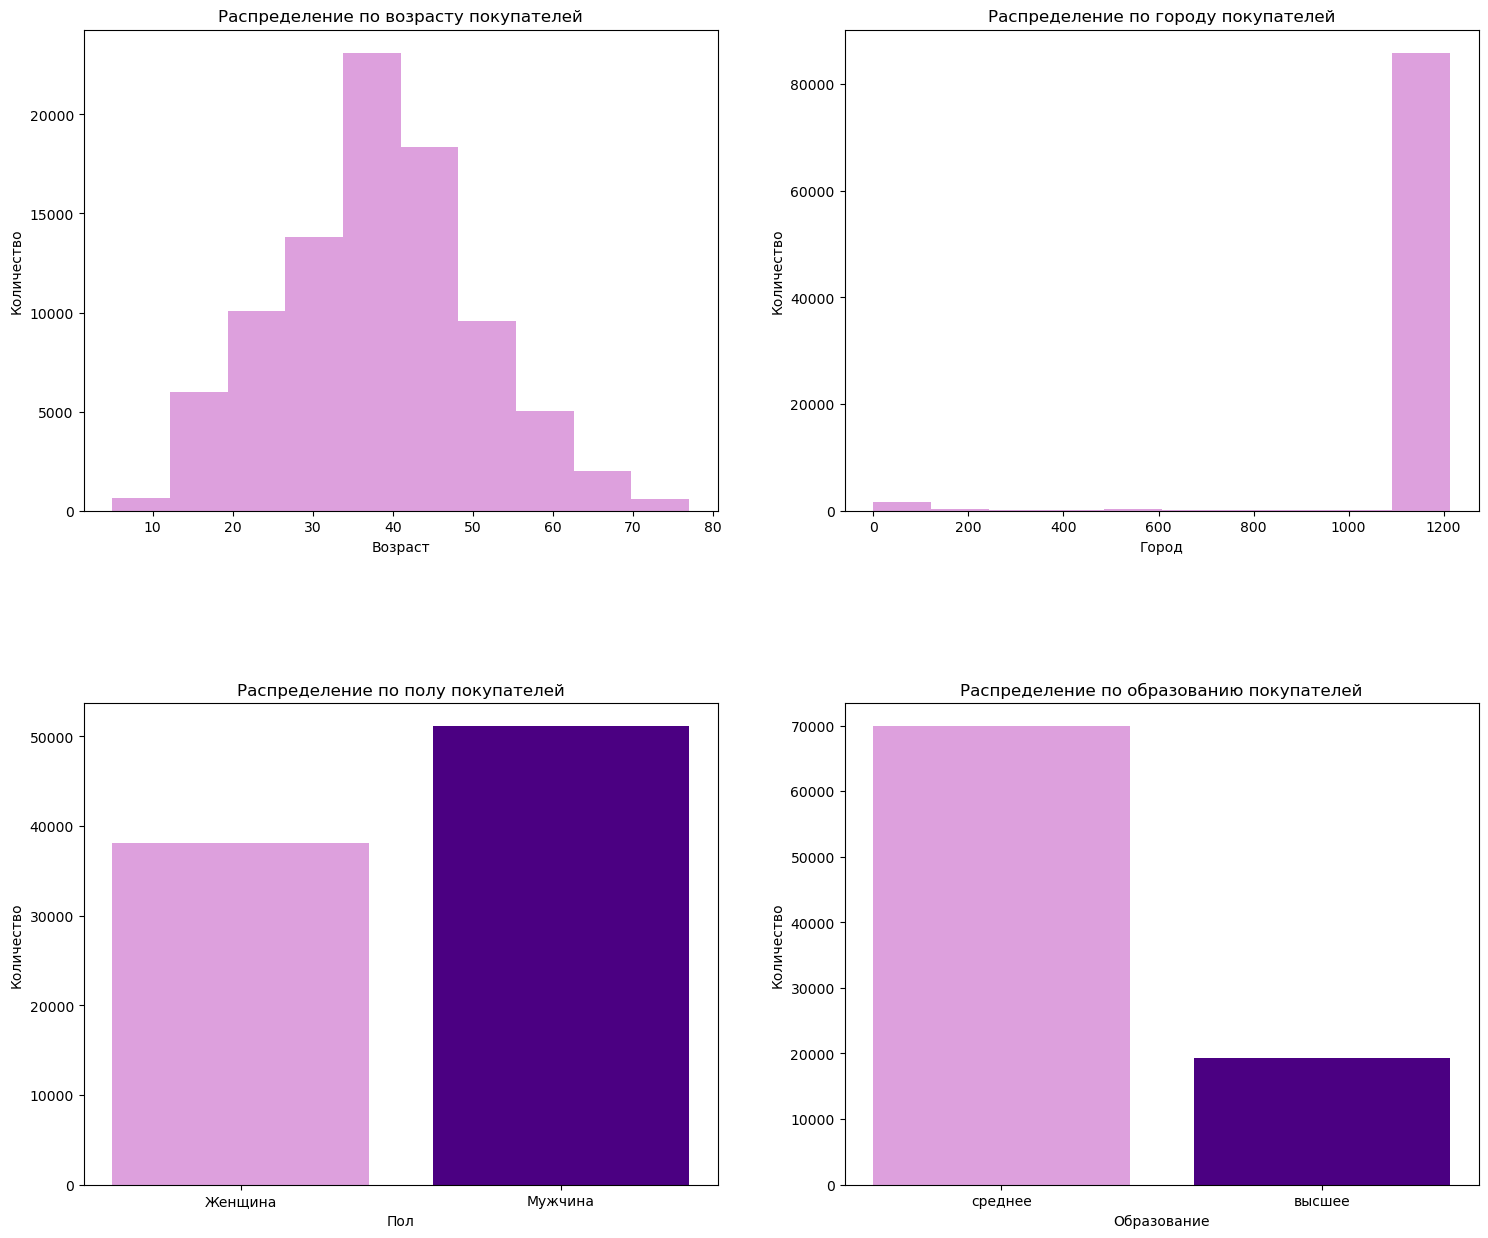

In [4]:
# Подсчёт количества
gender_counts = df_personal_data['gender'].value_counts().sort_index()
educ_counts = df_personal_data['education'].value_counts()

# Переименование категорий
gender_labels = {0: 'Женщина', 1: 'Мужчина'}

fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (18, 15))
fig.subplots_adjust(hspace = 0.4, wspace = 0.2)

ax[0, 0].hist(df_personal_data.age, color = 'Plum')
ax[0, 0].set_title("Распределение по возрасту покупателей")
ax[0, 0].set_xlabel('Возраст')
ax[0, 0].set_ylabel('Количество')

ax[1, 0].bar([gender_labels[i] for i in gender_counts.index], gender_counts.values, color=['Plum', 'Indigo'])
ax[1, 0].set_title("Распределение по полу покупателей")
ax[1, 0].set_xlabel('Пол')
ax[1, 0].set_ylabel('Количество')

ax[0, 1].hist(df_personal_data.city, color = 'Plum')
ax[0, 1].set_title("Распределение по городу покупателей")
ax[0, 1].set_xlabel('Город')
ax[0, 1].set_ylabel('Количество')

ax[1, 1].bar(educ_counts.index, educ_counts.values, color = ['Plum', 'Indigo'])
ax[1, 1].set_title("Распределение по образованию покупателей")
ax[1, 1].set_xlabel('Образование')
ax[1, 1].set_ylabel('Количество')

plt.show()

In [7]:
# Утерянные данные
df_data_lost = pd.read_csv('personal_data.csv')
df_data_lost.head()

,id,age,education,city,country
0,101492,32,среднее,1188,32
1,42690,20,высшее,1134,32
2,113001,27,среднее,1187,32
3,163654,49,высшее,1160,32
4,69523,44,среднее,1137,32


## Построение классификационной модели для восстановления пола в утерянных данных

#### Предобработка данных.

In [8]:
# Кодировка категориальных известных данных 
ore = OrdinalEncoder()
x1_ore = ore.fit_transform(df_personal_data[['education']])

df_personal_data_1 = df_personal_data.copy()
df_personal_data_1['education_ore'] = x1_ore

# Кодировка категориальных неизвестных данных 
x2_ore = ore.fit_transform(df_data_lost[['education']])
df_data_lost_1 = df_data_lost.copy()
df_data_lost_1['education_ore'] = x2_ore

In [9]:
# Сформируем столбцы Х и Y известных данных 
X = df_personal_data_1.drop(columns = ['education', 'gender', 'id', 'country'], axis = 1)
Y = df_personal_data_1['gender']

# Сформируем столбeц Х неизвестных данных 
X_lost = df_data_lost_1.drop(columns = ['education', 'id', 'country'], axis = 1)

In [10]:
# Нормализация данных
sc = StandardScaler()
X_sc = sc.fit_transform(X)

#### Построим несколько моделей предсказания и выберем лучшую

###### Логистическая модель

In [11]:
ln = LogisticRegression()
ln.fit(X_sc, Y)

# Посчитаем прогноз на известных данных
y_ln_pred = ln.predict(X_sc)

# Рассчет ошибок
mse_ln = np.sqrt(mean_squared_error(y_ln_pred, Y))
mae_ln = mean_absolute_error(Y, y_ln_pred)
print(f'Обычный прогноз: MSE = {round(mse_ln, 2)}, MAPE = {round(mae_ln, 2)}')

# Проверим на кросс-валидации
pl = Pipeline([('sc', sc), ('model', ln)])
y_ln_pred_cross = cross_val_predict(pl, X, Y)
mse_ln_cross = np.sqrt(mean_squared_error(y_ln_pred_cross, Y))
mae_ln_cross = mean_absolute_error(y_ln_pred_cross, Y)
print(f'Итоги при кросс-валидации: MSE = {round(mse_ln_cross, 2)}, MAE = {round(mae_ln_cross, 2)}')

Обычный прогноз: MSE = 0.65, MAPE = 0.43
Итоги при кросс-валидации: MSE = 0.65, MAE = 0.43


###### Модели на основе деревьев

In [12]:
dt = DecisionTreeClassifier()
dt.fit(X, Y)

# Посчитаем прогноз на известных данных
y_dt_pred = dt.predict(X)

# Рассчет ошибок
mse_dt = np.sqrt(mean_squared_error(y_dt_pred, Y))
mae_dt = mean_absolute_error(y_dt_pred, Y)
print(f'Обычный прогноз: MSE = {round(mse_dt, 2)}, MAPE = {round(mae_dt, 2)}')

# Проверим на кросс-валидации
y_dt_pred_cross = cross_val_predict(dt, X, Y)
mse_dt_cross = np.sqrt(mean_squared_error(y_ln_pred_cross, Y))
mae_dt_cross = mean_absolute_error(y_dt_pred_cross, Y)
print(f'Итоги при кросс-валидации: MSE = {round(mse_dt_cross, 2)}, MAE = {round(mae_dt_cross, 2)}')

Обычный прогноз: MSE = 0.61, MAPE = 0.37
Итоги при кросс-валидации: MSE = 0.65, MAE = 0.44


In [13]:
#Зададим глубину дерева, чтобы не дать ему переобучиться
dt_1 = DecisionTreeClassifier(max_depth = 7)
dt_1.fit(X, Y)

# Посчитаем прогноз на известных данных
y_dt1_pred_cross = cross_val_predict(dt_1, X, Y)

# Рассчет ошибок
mse_dt1_cross = np.sqrt(mean_squared_error(y_dt1_pred_cross, Y))
mae_dt1_cross = mean_absolute_error(y_dt1_pred_cross, Y)
print(f'Кросс-валидация при заданной глубине: MSE = {round(mse_dt1_cross, 2)}, MAE = {round(mae_dt1_cross, 2)}')

Кросс-валидация при заданной глубине: MSE = 0.65, MAE = 0.43


###### Случайный лес

In [14]:
rf = RandomForestClassifier()
rf.fit(X, Y)

# Посчитаем прогноз на известных данных
y_rf_pred = rf.predict(X)

# Рассчет ошибок
mse_rf = np.sqrt(mean_squared_error(y_rf_pred, Y))
mae_rf = mean_absolute_error(y_rf_pred, Y)
print(f'Обычный прогноз: MSE = {round(mse_rf, 2)}, MAE = {round(mae_rf, 2)}')

Обычный прогноз: MSE = 0.61, MAE = 0.37


In [15]:
#Зададим глубину дерева, чтобы не дать ему переобучиться
rf_1 = RandomForestClassifier(max_depth = 7)

# Посчитаем прогноз на известных данных
y_rf_1_pred_cross = cross_val_predict(rf_1, X, Y)

# Рассчет ошибок
mse_rf1_cross = np.sqrt(mean_squared_error(y_rf_1_pred_cross, Y))
mae_rf1_cross = mean_absolute_error(y_rf_1_pred_cross, Y)
print(f'Кросс-валидация при заданной глубине: MSE = {round(mse_rf1_cross, 2)}, MAE = {round(mae_rf1_cross, 2)}')

Кросс-валидация при заданной глубине: MSE = 0.65, MAE = 0.42


In [16]:
print("Логистическая модель")
print(f'Обычный прогноз: MSE = {round(mse_dt, 2)}, MAE = {round(mae_dt, 2)}')
print(f'Итоги при кросс-валидации: MSE = {round(mse_ln_cross, 2)}, MAE = {round(mae_ln_cross, 2)}\n')

print('Модель на основе деревьев')
print(f'Обычный прогноз: MSE = {round(mse_dt, 2)}, MAE = {round(mae_dt, 2)}')
print(f'Итоги при кросс-валидации: MSE = {round(mse_dt_cross, 2)}, MAE = {round(mae_dt_cross, 2)}')
print(f'Кросс-валидация при заданной глубине: MSE = {round(mse_dt1_cross, 2)}, MAE = {round(mae_dt1_cross, 2)}\n')

print('Случайный лес')
print(f'Обычный прогноз: MSE = {round(mse_rf, 2)}, MAE = {round(mae_rf, 2)}')
print(f'Кросс-валидация при заданной глубине: MSE = {round(mse_rf1_cross, 2)}, MAE = {round(mae_rf1_cross, 2)}')

Логистическая модель
Обычный прогноз: MSE = 0.61, MAE = 0.37
Итоги при кросс-валидации: MSE = 0.65, MAE = 0.43

Модель на основе деревьев
Обычный прогноз: MSE = 0.61, MAE = 0.37
Итоги при кросс-валидации: MSE = 0.65, MAE = 0.44
Кросс-валидация при заданной глубине: MSE = 0.65, MAE = 0.43

Случайный лес
Обычный прогноз: MSE = 0.61, MAE = 0.37
Кросс-валидация при заданной глубине: MSE = 0.65, MAE = 0.42


#### Модели  несколько переобучаются на известных данных, при кросс-валидации результаты практически одинаковы у всех моделей. Воспользуемся моделью случайного леса для прогноза пола клиентов на потерянных данных, т.к. у него чть лучше результаты.

In [17]:
rf_1.fit(X, Y)
y_gender_lost_pred = rf_1.predict(X_lost)

# Добавим прогнозные данные в массив
df_data_lost['gender'] = y_gender_lost_pred
df_data_lost.head()

,id,age,education,city,country,gender
0,101492,32,среднее,1188,32,1
1,42690,20,высшее,1134,32,1
2,113001,27,среднее,1187,32,1
3,163654,49,высшее,1160,32,1
4,69523,44,среднее,1137,32,0


## Объединим все данные в один датафрейм

In [18]:
# Объединим информацию об покупателях в один датафрейм
df_personal_data = pd.concat([df_personal_data, df_data_lost])
df_personal_data.head()

,id,gender,age,education,city,country
0,0,0,36,среднее,1201,32
1,4,0,35,среднее,1134,32
2,6,1,52,среднее,1188,32
3,7,0,37,среднее,1198,32
4,9,0,48,среднее,1134,32


In [19]:
df = df_personal_data.merge(df_purchases, on = 'id', how = 'left').merge(df_coeff, on = 'id', how = 'left')
df = df[df.country == 32]
df.head()

,id,gender,age,education,city,country,product,colour,cost,product_sex,base_sale,dt,personal_coef
0,0,0,36,среднее,1201,32,"Велосипед горный женский Stern Mira 2.0 26""",белый/синий,13599,0.0,1,7,0.5072
1,0,0,36,среднее,1201,32,Стол Outventure,зелёный,1499,NaN,0,37,0.5072
2,0,0,36,среднее,1201,32,Набор Outventure: стол + 4 стула,бежевый,4799,NaN,0,37,0.5072
3,4,0,35,среднее,1134,32,Роликовые коньки детские Roces Orlando III,черный/розовый,9199,NaN,0,0,0.5072
4,4,0,35,среднее,1134,32,Шлем FILA NRK FUN,белый,4999,NaN,0,0,0.5072


###### Посмотрим, как поменялось распрделение по полу клиентов

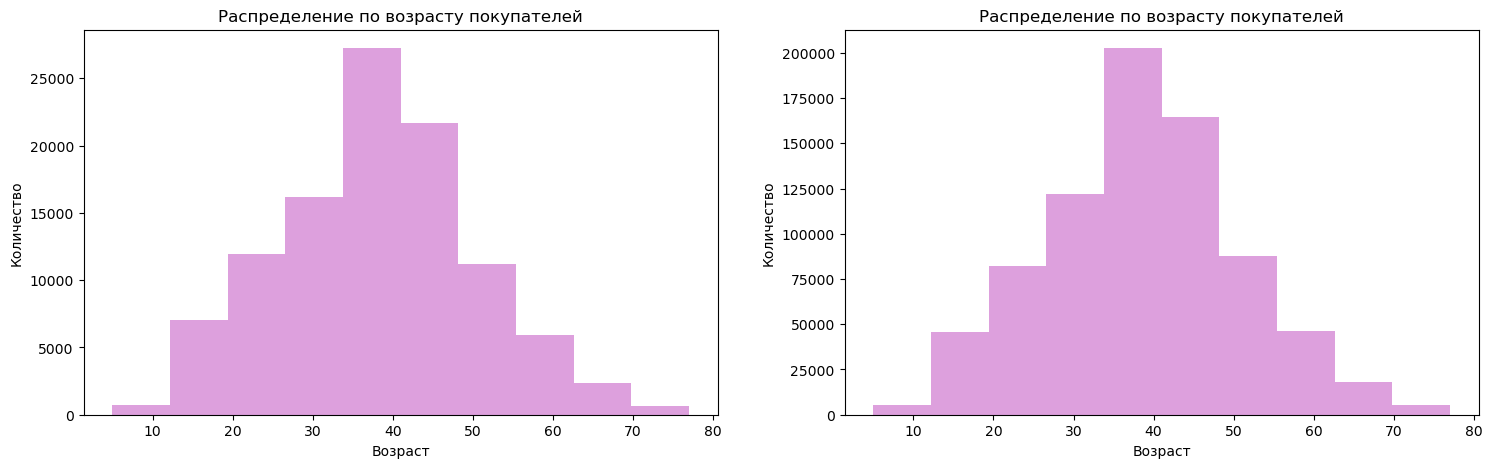

In [25]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (18, 5))
fig.subplots_adjust(hspace = 0.4, wspace = 0.2)

ax[0].hist(df_personal_data.age, color = 'Plum')
ax[0].set_title("Распределение по возрасту покупателей")
ax[0].set_xlabel('Возраст')
ax[0].set_ylabel('Количество')

ax[1].hist(df.age, color = 'Plum')
ax[1].set_title("Распределение по возрасту покупателей")
ax[1].set_xlabel('Возраст')
ax[1].set_ylabel('Количество')

plt.show()

## A/В-тестирование

In [26]:
# Функция читает списки id
def read_list_id(name):
    with open(name, 'r', encoding='utf-8') as file:
        content = file.read()

    # Запишем в один файл нечисловые значение, во второй - числовые
    notdigit = [x.strip()for x in re.split(r'\W+', content.strip()) if not x.strip().isdigit()]
    id_list = [int(x.strip()) for x in re.split(r'\W+', content.strip()) if x.strip().isdigit()]

    # Если в элементах нечислового списка есть числа, то дозапишем их в исходный
    for x in notdigit:
        dop = re.findall(r'\d+', x)
        id_list.extend(dop)

    # Удалим дубликаты
    id_list = list(set(id_list))
    
    return id_list

In [27]:
# Прочитаем файл файл с первой кампанией с id, которым дали персональную скидку
id_with_sale = read_list_id('ids_first_company_positive.txt')
id_without_sale = read_list_id('ids_first_company_negative.txt')

#### Сформируем тестовую и контрольную группы

In [28]:
df_test = df[(df.id.isin(id_with_sale)) & (df['dt'] > 4) & (df['dt'] < 17)]
df_control = df[df.id.isin(id_without_sale) & (df['dt'] > 4) & (df['dt'] < 17)]

In [29]:
# Размер тестовой группы
print(f'Размер тестовой группы: {df_test.shape}')

# Размер контрольной группы
print(f'Размер контрольной группы: {df_control.shape}')

Размер тестовой группы: (24959, 13)
Размер контрольной группы: (19876, 13)


In [30]:
df_test.head()

,id,gender,age,education,city,country,product,colour,cost,product_sex,base_sale,dt,personal_coef
0,0,0,36,среднее,1201,32,"Велосипед горный женский Stern Mira 2.0 26""",белый/синий,13599,0.0,1,7,0.5072
12,6,1,52,среднее,1188,32,Футболка мужская Kappa Authentic Core,темно-синий,999,1.0,0,8,0.4304
13,6,1,52,среднее,1188,32,Бейсболка детская Nike Futura Mash Up,синий,1119,NaN,1,11,0.4304
14,6,1,52,среднее,1188,32,"Носки детские Demix, 2 пары",синий/серый,299,NaN,0,11,0.4304
15,6,1,52,среднее,1188,32,Кроссовки мужские adidas Lite Racer CLN 2.0,черный,7399,1.0,0,11,0.4304


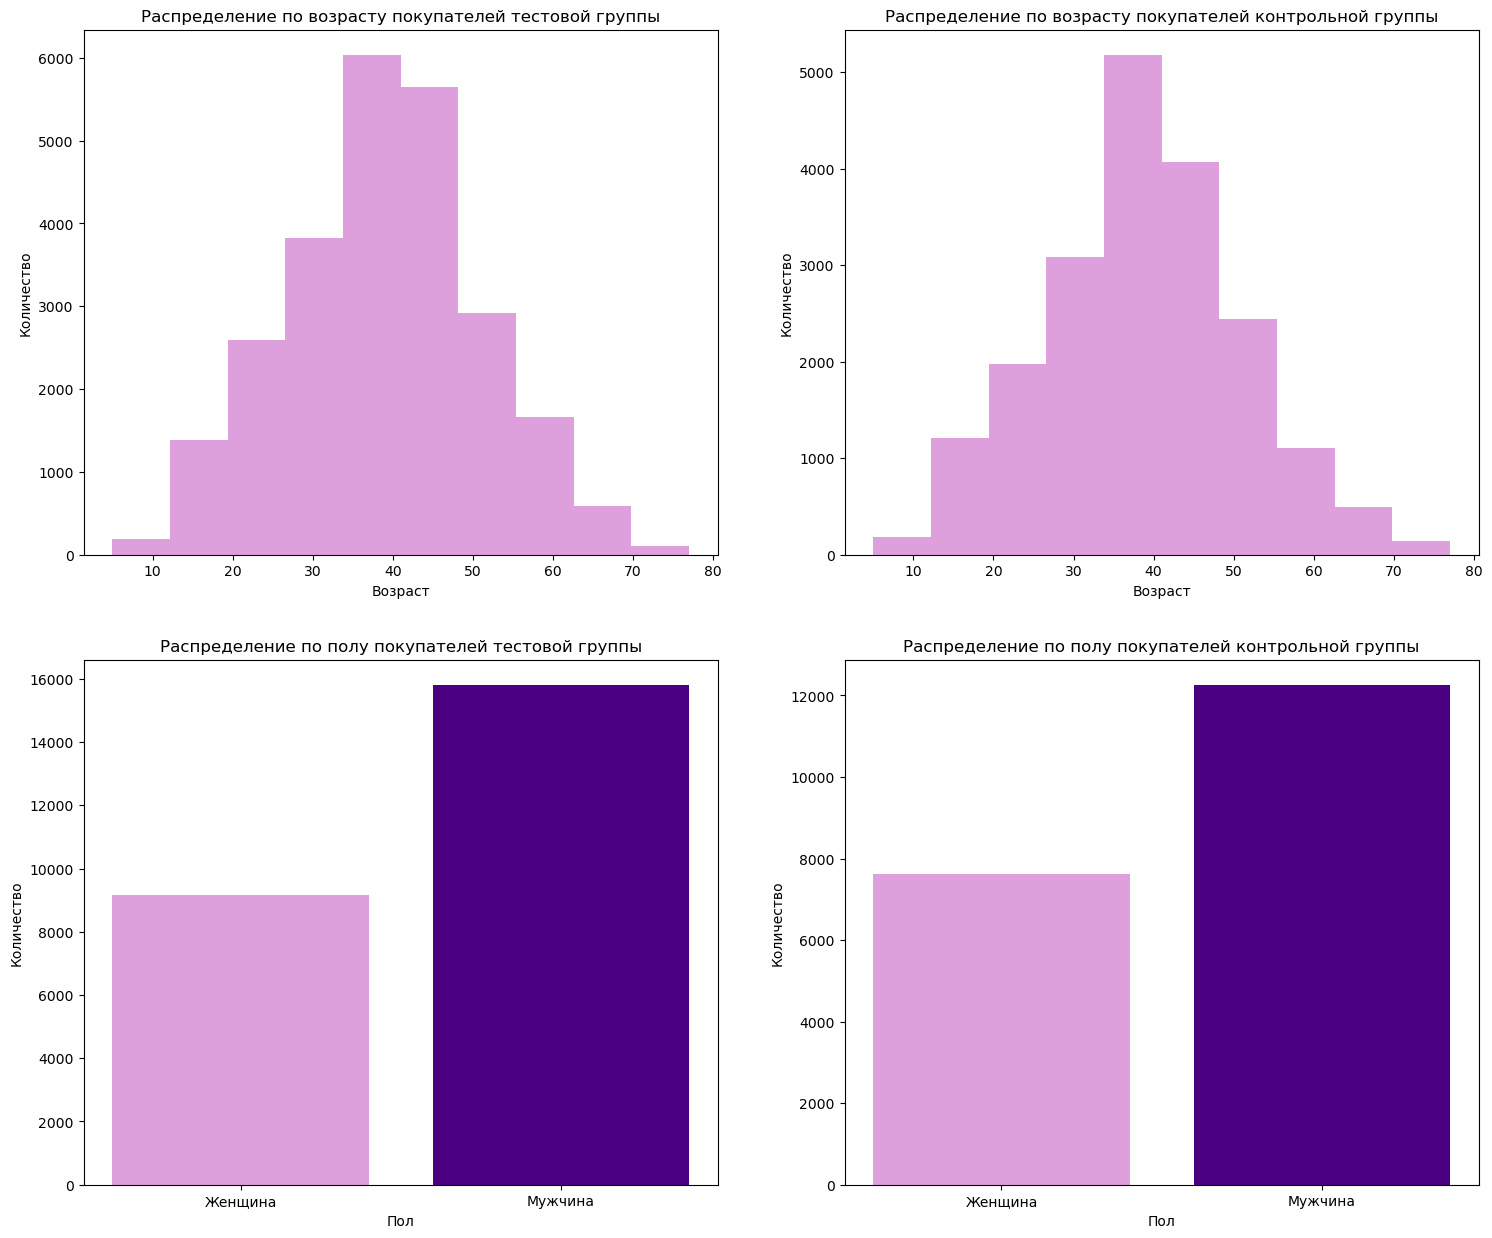

In [33]:
# Подсчёт количества
gender_test = df_test['gender'].value_counts().sort_index()
gender_control = df_control['gender'].value_counts().sort_index()

# Переименование категорий
gender_labels = {0: 'Женщина', 1: 'Мужчина'}

fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (18, 15))
fig.subplots_adjust(hspace = 0.2, wspace = 0.2)

ax[0, 0].hist(df_test.age, color = 'Plum')
ax[0, 0].set_title("Распределение по возрасту покупателей тестовой группы")
ax[0, 0].set_xlabel('Возраст')
ax[0, 0].set_ylabel('Количество')

ax[0, 1].hist(df_control.age, color = 'Plum')
ax[0, 1].set_title("Распределение по возрасту покупателей контрольной группы")
ax[0, 1].set_xlabel('Возраст')
ax[0, 1].set_ylabel('Количество')

ax[1, 0].bar([gender_labels[i] for i in gender_test.index], gender_test.values, color=['Plum', 'Indigo'])
ax[1, 0].set_title("Распределение по полу покупателей тестовой группы")
ax[1, 0].set_xlabel('Пол')
ax[1, 0].set_ylabel('Количество')

ax[1, 1].bar([gender_labels[i] for i in gender_control.index], gender_control.values, color=['Plum', 'Indigo'])
ax[1, 1].set_title("Распределение по полу покупателей контрольной группы")
ax[1, 1].set_xlabel('Пол')
ax[1, 1].set_ylabel('Количество')

plt.show()

###### Посчитаем значения основных метрик: соотношение количества купивших по скидке к общему числу

In [34]:
shape_buy_for_sale_test = df_test[df_test['base_sale'] == 1].shape[0]/df_test.shape[0] * 100
shape_buy_for_sale_control = df_control[df_control['base_sale'] == 1].shape[0]/df_control.shape[0] * 100

print(f'Cоотношение количества купивших по скидке к общему числу покупателей в тестовой группе: {round(shape_buy_for_sale_test, 2)}%, \
в контрольной: {round(shape_buy_for_sale_control, 2)}%')

Cоотношение количества купивших по скидке к общему числу покупателей в тестовой группе: 30.05%, в контрольной: 30.14%


###### Посчитаем вспомогательные метрики: среднюю цену чека

In [35]:
receipt_mean_test = df_test.cost.mean()
receipt_mean_control = df_control.cost.mean()

print(f'Cредний чек в тестовой группе: {round(receipt_mean_test, 2)} д.е., в контрольной: {round(receipt_mean_control, 2)} д.е.')

Cредний чек в тестовой группе: 5312.0 д.е., в контрольной: 5590.45 д.е.


##### Проведем статистический тест

###### Сформулируем гипотезы:
H₀: Разницы между соотношением количества купивших по скидке к общему числу покупателей контрольной и тестовой групп нет.

H₁: Разница между соотношением количества купивших по скидке к общему числу покупателей контрольной и тестовой групп есть.

In [36]:
# Подготовим данные
data_test_sale = df_test.base_sale
data_control_sale = df_control.base_sale

###### Проверим условия для проведения теста:
Равенство дисперсий (можно проверить с помощью теста Левена)

Нормальность распределения данных (тест Шапиро–Уилка)

In [37]:
stat, p_value = levene(data_test_sale, data_control_sale)
print(f"p-значение: {p_value:.3f}")

# Интерпретация результатов
if p_value < 0.05:
    print("Разброс значений статистически различается — дисперсии не равны.")
else:
    print("Нет значимой разницы в дисперсиях — можно считать дисперсии равными.")


p-значение: 0.848
Нет значимой разницы в дисперсиях — можно считать дисперсии равными.


In [38]:
stat, p_value = shapiro(data_test_sale)
print(f"p-значение: {p_value:.3f}")

# Интерпретация
if p_value < 0.05:
    print("Распределение отличается от нормального.")
else:
    print("Распределение можно считать нормальным.")

p-значение: 0.000
Распределение отличается от нормального.


C:\Users\pental_sv\Anaconda3\lib\site-packages\scipy\stats\_morestats.py:1800: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


In [39]:
stat, p_value = shapiro(data_control_sale)
print(f"p-значение: {p_value:.3f}")

# Интерпретация
if p_value < 0.05:
    print("Распределение отличается от нормального.")
else:
    print("Распределение можно считать нормальным.")

p-значение: 0.000
Распределение отличается от нормального.


###### Используем t-test

In [40]:
stat, p_value = ttest_ind(data_test_sale, data_control_sale, equal_var = True)
print(f"p-значение: {p_value:.3f}")

# Вывод интерпретации
if p_value < 0.05:
    print("Разница между группами статистически значима.")
else:
    print("Нет доказательств значимой разницы между группами.")

p-значение: 0.848
Нет доказательств значимой разницы между группами.


##### Вывод: Предоставление скидки через email-рассылку не повысила покупаемость товаров. Возможно, это говорит о том, что проведение акции таким образом не самый лучший способ. Стоит рассмотреть другие варианты привлечения клиентов, в том числе и предоставление персональной скидки. Например, воспользоваться смс-рассылкой на телефон или мессенджеры.

### Кластеризация

##### Разделим все товары на группы (укрупним)

In [41]:
female = ['женск', 'Платье', 'women', 'Юбка', 'bra']
girl = ['девоч']
male = ['мужск', 'men']
boy = ['мальч', 'boy', 'Юниорские']
baby = ['детск']
sport_invertar = ['Велосипед', 'коньки', 'Шлем', 'Насос', 'Ворот', 'Мяч', 'Лодк', 'крыл', 'Стол', 'Электросамокат ', 
                  'Спальный мешок', 'Палатк', 'Коврик', 'Спиннинг', 'Матрас ', 'Палк', 'Тент', 'Кресл', 'Диск', 
                  'платформ', 'степпер', 'Ракетк', 'Гантел', 'Круизер', 'Сноуборд', 'Каретка', 'Мешок',  'Маск', 'SUP', 
                  'Тренажер', 'Самокат', 'Ролик', 'Эспандер', 'Кольцо', 'стойк', 'лыж', 'Обруч', 'Скейтборд', 'Мультитул',
                  'Скакалк', 'Гамак', 'Байдарк', 'станц', 'Пила', 'Сноускейт', 'Батут', 'Лонгборд', 'Бафф', 
                  'Детский спортивный комплекс', 'Барабан', 'Тюбинг', 'Медицинбол', 'Дартс', 'Нунчаки', 'Катамаран', 
                  'Gladiator', 'Барьер', 'Cамокат', 'Фрисби', 'Пакрафт', 'tennis', 'Фитбол', 'Твистер', 'ball', 'скутер', 
                  'Снегокат']
other_inventar = ['Лестниц', 'Дорожк', 'Фишки', 'Чехлы', 'Фонар', 'Леск', 'Нож', 'Флягодержател', 'Бутылк', 'Дезодорант', 
                  'посуд', 'Термос', 'Защита', 'Фитнес-браслет', 'Кроват', 'Крепления', 'Скамь', 'Игр', 'бра', 'Миск', 
                  'Гель', 'Щитки', 'салфетк', 'Фляжк', 'Напульсник', 'Подушк', 'Вилк', 'Стул', 'Стрессбол', 'горелк', 
                  'Кухня', 'Аэрозоль', 'Одеяло', 'тейп', 'Гриф', 'Суппорт', 'растяжк', 'Кружк', 'Ложк', 'Чехол', 'сетк', 
                  'Сидушк', 'баллон', 'Варежки', 'Наколенник', 'Налокотник', 'Крем', 'Воблер', 'Пакет', 'ламп', 'Лент', 
                  'Чайник', 'Станок', 'Часы', 'Эхолот', 'Секундомер', 'Термоконтейнер', 'Огниво', 'Лопат', 'Обруч', 
                  'Дождевик', 'Монитор', 'Кап', 'Лап', 'Карабин', 'Антифог', 'Щит', 'Основание ', 'Пропитк', 'Ласт', 
                  'Ремень', 'Струн', 'Котелок', 'Средств', 'Мазь', 'Щетк', 'Колпачки', 'Волан', 'Затачиватель', 'Фляг', 
                  'Скакалк', 'Клюшк', 'Грипсы', 'бинт', 'Камер', 'Трос', 'Беруши', 'Котелок', 'бит', 'Витамин', 'рул', 
                  'тормоз', 'Камер', 'Коллаген', 'Пуллер', 'Добавк', 'Подпяточник', 'Креплен', 'Пояс', 'Плед', 'Шнурки', 
                  'Массажер', 'батончик', 'Петл', 'Аккумулятор', 'Ремни', 'трекер', 'Колобашк', 'Котел', 'Седло', 'Грелк', 
                  'Бассейн', 'Зажим', 'цеп', 'Шампур', 'полусфер', 'Катушк', 'Наконечник', 'Смывк', 'Спрей', 'Гир', 
                  'Вес', 'Клистер', 'Беговел', 'Матрац', 'Блин', 'Мишен', 'Шингарт', 'Велоэргометр', 'Изотоник', 'Душ', 
                  'Флаг', 'Блесн', 'Ключ', 'Чемодан', 'Половник', 'Сушк', 'Маркер', 'Несессер', 'штыр', 'Удилищ', 
                  'Велопедал', 'Турник', 'Шайб', 'Гейнер', 'Зеркал', 'Протеин', 'Аминокислот', 'Подставк', 'Мюсли', 
                  'Козырек', 'Дротик', 'Губк', 'Стакан', 'Брус', 'Багажник', 'борд', 'систем', 'Шифтер', 'карнитин', 
                  'Репшнур', 'Монтажк', 'Губк', 'Стакан', 'Брус', 'Багажник', 'борд', 'систем', 'Шифтер', 'карнитин', 
                  'Репшнур', 'Монтажк', 'Разметк', 'Мультиинструмент', 'саун', 'Таганок', 'Держател', 'Тюбинг', 'печен', 
                  'Виброхвост', 'Рация', 'Доск', 'Кардиодатчик', 'цилиндр', 'Утяжелител', 'Kлюшк', 'Намотк', 'Нагрудник', 
                  'Подсачек', 'Снегоступ', 'Брелок', 'Круг', 'Виброгасител', 'Строп', 'Гермобаул', 'Топор', 'Трубк', 
                  'Фьюз', 'стяжк', 'Лиш', 'Безмен', 'центр', 'Хвостовик', 'Ящик', 'Мат', 'Фартук', 'карт', 'Груш', 
                  'Магнезия', 'Треног', 'Бинокл', 'Макивар', 'Велокомпьютер', 'Педал', 'Таймер', 'кораблик', 'Оголовник',
                  'вод', 'балон', 'Кольц', 'Туб', 'Тарелк', 'Мака', 'панел', 'Таз', 'Звонок', 'Булав', 'Бумеранг', 
                  'Нарукавник', 'Борцовк', 'Канат', 'Батарейк', 'комплекс', 'Блок', 'Смазк', 'Инструмент', 'Спичк', 'Стик', 
                  'резак', 'Мелатонин', 'пен', 'Тиск', 'Шейкер', 'Рукав', 'Cуппорт', 'Катамаран', 'Упор', 'Чашк', 
                  'адаптер', 'парашют', 'пробк', 'Баул', 'корзин', 'Конус', 'Креатин', 'Вставк', 'Манжет', 'утюг', 
                  'Растяжител', 'сигнал', 'Щуп', 'Замок', 'Наклейк', 'Экран', 'крюк', 'Кофемолк', 'ведр', 'Крючок', 
                  'краск', 'Шланг', 'Фильтр', 'устройств', 'Накладки', 'горючее', 'роллер', 'Лук', 'Разогревател', 
                  'Шагомер', 'каяк', 'Аптечк', 'Свисток', 'Намёт', 'Энергетик', 'Вентилятор', 'Канторез', 'Футляр', 
                  'Затягиватель', 'Контейнер', 'Очиститель', 'Компресс', 'Камус', 'указка', 'Плоскогубцы', 'батареек', 
                  'Наушники', 'камень', 'Чапельник', 'Грипса', 'Эргометр', 'кислот', 'Помада', 'Переходник', 'Решетк', 
                  'Звезд', 'Глютамин', 'Гидролиния', 'Манометр', 'Компас', 'Сквиш', 'BCAA', 'Веревк', 'Щепочниц', 
                  'Бодибар', 'Панкейк', 'Надставк', 'Жиросжигател', 'Визор', 'конец', 'Бассеин', 'Лосьон', 'Санки', 
                  'Ось', 'карандаш', 'Лезвия', 'жир', 'Пиколинат', 'Подсумок', 'Светильник', 'Регулятор', 'Плоскогубцы', 
                  'червь', 'Косметичк', 'ледянка', 'приманк', 'Гребенк', 'Имитатор', 'Мангал', 'Резервуар', 'Воск', 
                  'Фибертекс', 'Свимбейт', 'Кастрюл', 'Кофеварк', 'Спираль', 'Оперения', 'Заплатк', 'язык', 'Коптильня', 
                  'Пульсометр', 'Брызговик', 'computer', 'Кофеварк', 'Спираль', 'Крышк', 'Бандаж', 'колышек', 'спиннер', 
                  'Коробк', 'Watch', 'Темляк', 'Аквагрим', 'Скребок', 'Органайзер', 'Щипцы', 'Сушилк', 'Буксир', 
                  'Ремонтный комплект', 'клапан', 'Покрышк', 'Подножк', 'Мультиключ', 'Каретк', 'Набор', 'Втулк', 
                  'колес', 'монтажек', 'ручк', 'шатун', 'переключател', 'Бушинги', 'Cмазк', 'Шарнир']
unisex = ['Гетры', 'Шапк', 'Панам', 'Сабо', 'Носки', 'очки', 'Бейсболк', 'Гейтор', 'Повязк', 'Перчатк', 'Ботинк', 'Трико',
          'обув', 'Худи', 'Куртк', 'Гольфы', 'Полотенц', 'Шлепанцы', 'топ', 'Кроссовки', 'Кошелек', 'Свитшот', 'Пряжк', 
          'Джерси', 'Шапочк', 'Гамаши', 'Стельки', 'Брюки', 'Футболк', 'Шорты', 'Сандалии', 'Кеды', 'Кимоно',
          'Куртка', 'Комплект', 'Жилет', 'Толстовк', 'купальник', 'Туфли', 'Пальто', 'Добок',  'Бандан', 'Джемпер',
          'Свитер', 'Рубашк', 'Пуховик', 'Шарф', 'Борцовк', 'Балаклав', 'Кепк', 'Боксерки', 'Комбинезон', 'Халат', 
          'Гидрокостюм', 'Снуд', 'Майк', 'Кальсоны', 'Рейтузы', 'Получешки', 'Термобелье', 'Подтяжки', 'socks',
          'Сумк', 'Рюкзак', 'Легинсы']
other = ['Demix fitness gloves red', 'Сапоги Tecnica Moon Boot', '男士靴子 Northland Graz LTR 深棕色', 
         'Giày thể thao PUMA Twitch Runner dành cho nữ Màu hồng / trắng / đen tươi',  'Quần tây nam FILA đen', 
         'Giày nam Demix Exponenta 3 Fg đỏ/trắng', 'Demix 袜子，3 双黑色',  'Termit HawaII 蓝色/米色男士拖鞋', 
         'Joss Joy 深蓝色拖鞋', "蛋白质棒 Forsio ''Orange Rough'' 50 g 多色", 'FILA 蓝色男士泳裤', 
         "男士软壳夹克Arc'teryx Gamma 深蓝色"]

In [42]:
dict_group_product = {
    'female': 'Женские товары',
    'girl': 'Товары для девочек',
    'male': 'Мужские товары',
    'boy': 'Товары для мальчиков',
    'baby': 'Детские товары',
    'sport_invertar': 'Спортивные товары',
    'other_inventar': 'Другие товары для спорта и отдыха',
    'unisex': 'Унисекс',
    'other': 'Другое'
}

In [43]:
# Определение группы товара
def assign_group(x):
    if not isinstance(x, str):
        return dict_group_product['other']
    
    x_lower = x.lower()
    
    if any(word in x_lower for word in female):
        return dict_group_product['female']
    elif any(word in x_lower for word in girl):
        return dict_group_product['girl']
    elif any(word in x_lower for word in male):
        return dict_group_product['male']
    elif any(word in x_lower for word in boy):
        return dict_group_product['boy']
    elif any(word in x_lower for word in baby):
        return dict_group_product['baby']
    elif any(word in x_lower for word in sport_invertar):
        return dict_group_product['sport_invertar']
    elif any(word in x_lower for word in other_inventar):
        return dict_group_product['other_inventar']
    elif any(word in x_lower for word in unisex):
        return dict_group_product['unisex']
    else:
        return dict_group_product['other']

In [44]:
df['product_group'] = df['product'].apply(assign_group)

##### На основании столбца product_group заполним product_sex

In [45]:
dict_product_sex = {
    'Женские товары': 0,
    'Товары для девочек': 0,
    'Мужские товары': 1,
    'Товары для мальчиков': 1,
    'Детские товары': 3,
    'Спортивные товары': 4,
    'Другие товары для спорта и отдыха': 4,
    'Унисекс': 2,
    'Другое': 5
}

In [46]:
# Определение product_sex
def assign_product_sex(x):
    if isinstance(x, (int, float)):
        return x
     
    if x == 'Женские товары':
        return dict_product_sex['Женские товары']
    if x == 'Товары для девочек':
        return dict_product_sex['Товары для девочек']
    if x == 'Мужские товары':
        return dict_product_sex['Мужские товары']
    if x == 'Товары для мальчиков':
        return dict_product_sex['Товары для мальчиков']
    if x == 'Детские товары':
        return dict_product_sex['Детские товары']
    if x == 'Спортивные товары':
        return dict_product_sex['Спортивные товары']
    if x == 'Другие товары для спорта и отдыха':
        return dict_product_sex['Другие товары для спорта и отдыха']
    if x == 'Унисекс':
        return dict_product_sex['Унисекс']
    else:
        return dict_product_sex['Другое']

In [47]:
df['product_sex'] = df['product_group'].apply(assign_product_sex)

##### Разделим все цвета на группы (укрупним)

In [48]:
multi_colored = ['/', '-', 'Мульти', 'милитари', 'хаки', 'принт', 'разноцвет', 'леопардовый', 'камуфляж', 'хамелеон',
                'клетка', 'перламутровый', 'цветной', 'многоцветный', 'мультицвет', 'разноцветный']
white_color = ['белый', 'молочный', 'прозрачный', 'пудровый', 'кость', 'бесцветный', 'пастельный', 'мел', 'натуральный',
            'экрю', 'нюд', 'бeлый']
black_color = ['черный', 'чёрный', 'обсидиан', 'антрацит']
green_color = ['зелёный', 'салатовый', 'зеленый', 'фисташковый', 'оливковый', 'еловый', 'болотный', 'лайм', 'бирюзовый',
              'хвойный', 'мятный', 'изумруд', 'горчичный', 'малахитовый', 'петроль', 'кирпичный', 'янтарный', 'бронзовый',
              'авокадо', 'травяной']
brown_color = ['бежевый', 'коричневый', 'ореховый', 'терракотовый', 'кремовый', 'мед', 'оранжевый', 'абрикосовый', 
               'охра', 'кофейный', 'песочный', 'какао', 'персиковый', 'каштановый', 'дерево', 'латте', 'глиняный']
gray_color = ['серый', 'графит', 'серебр', 'дымчатый', 'металл', 'асфальтовый', 'пепельный', 'стальной', 'гранитный',
             'хром', 'никель', 'оловянный']
blue_color = ['синий', 'голубой', 'морской', 'небесный', 'сапфировый', 'васильковый', 'сиинй', 'лазурный', 'аквамарин',
             'ультрамарин', 'волн']
yellow_color = ['желтый', 'жёлтый', 'золотой', 'яблочный', 'лимонный', 'золот', 'титаниум', 'яблоко', 'солнечный']
red_color = ['розовый',   'красный', 'коралл', 'пионовый', 'лососевый', 'алый', 'морковный', 'малиновый', 'ягодный',
            'кедровый']
purple_color = ['фиолетовый', 'индиго', 'фиалковый', 'фуксия', 'черничный','лавандовый', 'сиреневый', 'орхидея', 'вереск',
               'ирис', 'пурпурный', 'ежевичный']
burgundy_color = ['сливовый', 'баклажановый', 'вишн', 'бордовый',  'винный', 'виноградный', 'лиловый', 'бургунди', 'бордо']
other_color = ['матовый', 'точка', 'меланж', 'pel', 'htpk', 'pehl', 'hps', 's', 'pk', 'bgh', 'cb', 'gsu', 'ft', 'дай', 
              'неопределённый', 'нейтральный', 'bg', 'паук', 'варио', 'глянцевый', 'неоновый', 'зеркальный', 'inc', 'g',
               'ht', 'c', 'pwrt', 'шторм', 'джунгли', 'тату', 'dbp', 'tr', 'rol', 'mbt']

In [49]:
dict_color_group = {
    'multi_colored': 'Разноцветный',
    'white_color': 'Светлый',
    'black_color': 'Черный',
    'green_color': 'Зеленый',
    'brown_color': 'Коричневый',
    'gray_color': 'Серый',
    'blue_color': 'Синий',
    'yellow_color': 'Желтый',
    'red_color': 'Красный',
    'purple_color': 'Фиолетовый',
    'burgundy_color': 'Бордовый',
    'other_color': 'Другой цвет'
}

In [50]:
# Определение группы по цвету
def assign_color_group(x):
    if not isinstance(x, str):
        return dict_color_group['other_color']
    
    x_lower = x.lower()
    
    if any(word in x_lower for word in multi_colored):
        return dict_color_group['multi_colored']
    elif any(word in x_lower for word in white_color):
        return dict_color_group['white_color']
    elif any(word in x_lower for word in black_color):
        return dict_color_group['black_color']
    elif any(word in x_lower for word in green_color):
        return dict_color_group['green_color']
    elif any(word in x_lower for word in brown_color):
        return dict_color_group['brown_color']
    elif any(word in x_lower for word in gray_color):
        return dict_color_group['gray_color']
    elif any(word in x_lower for word in blue_color):
        return dict_color_group['blue_color']
    elif any(word in x_lower for word in yellow_color):
        return dict_color_group['yellow_color']
    elif any(word in x_lower for word in red_color):
        return dict_color_group['red_color']
    elif any(word in x_lower for word in purple_color):
        return dict_color_group['purple_color']
    elif any(word in x_lower for word in burgundy_color):
        return dict_color_group['burgundy_color']
    else:
        return dict_color_group['other_color']

In [51]:
df['color_group'] = df['colour'].apply(assign_color_group)

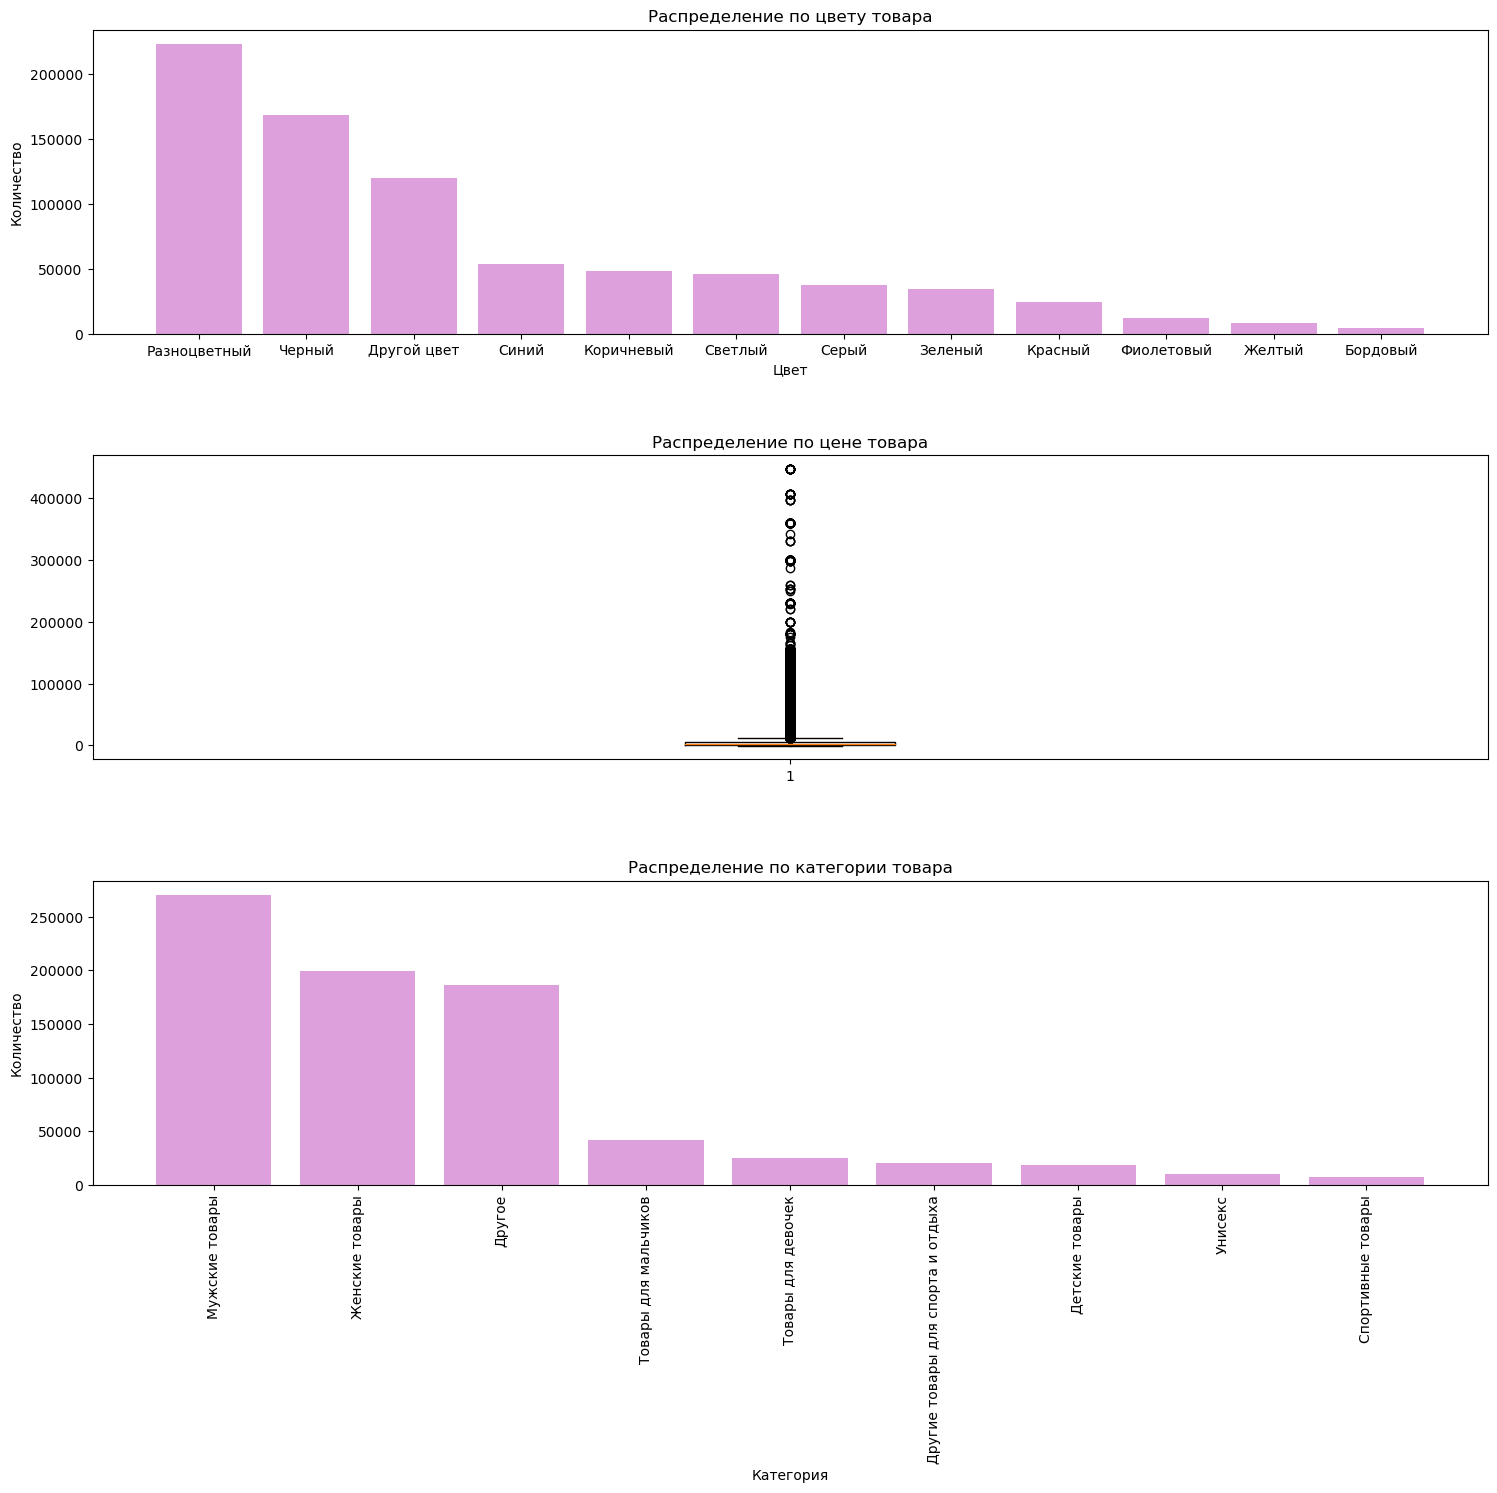

In [53]:
# Подсчёт количества
color_counts = df.color_group.value_counts()
prod_counts = df.product_group.value_counts()

fig, ax = plt.subplots(nrows = 3, ncols = 1, figsize = (18, 15))
fig.subplots_adjust(hspace = 0.4, wspace = 0.2)

ax[0].bar(color_counts.index, color_counts.values, color = 'Plum')
ax[0].set_title("Распределение по цвету товара")
ax[0].set_xlabel('Цвет')
ax[0].set_ylabel('Количество')

ax[1].boxplot(df.cost)
ax[1].set_title("Распределение по цене товара")

ax[2].bar(prod_counts.index, prod_counts.values, color = 'Plum')
ax[2].tick_params(axis='x', rotation=90)
ax[2].set_title("Распределение по категории товара")
ax[2].set_xlabel('Категория')
ax[2].set_ylabel('Количество')

plt.show()

##### Сформируем датафрейм, который будем использовать при кластеризации. Неинформативны столбцы: id, country, product, colour, dt

In [55]:
df_clustering = df.drop(columns = ['id', 'country', 'product', 'colour', 'dt'], axis = 1)
df_clustering.head()

,gender,age,education,city,cost,product_sex,base_sale,personal_coef,product_group,color_group
0,0,36,среднее,1201,13599,0,1,0.5072,Женские товары,Разноцветный
1,0,36,среднее,1201,1499,5,0,0.5072,Другое,Зеленый
2,0,36,среднее,1201,4799,5,0,0.5072,Другое,Коричневый
3,0,35,среднее,1134,9199,3,0,0.5072,Детские товары,Разноцветный
4,0,35,среднее,1134,4999,5,0,0.5072,Другое,Светлый


### Так как у нас как числовые, так и категориальные переменные, поэтому при кластеризаци воспользуемся методом KPrototypes

###### Разделим переменные на числовые и категориальные.

In [123]:
# Числовые данные
num_col = df_clustering.select_dtypes(exclude = 'object').columns.tolist()

list_change = ['gender', 'city', 'product_sex']
for item in list_change:
    num_col.remove(item)

In [124]:
# Категориальные данные
categ_idx = [df_clustering.columns.get_loc(col) for col in list(df_clustering.select_dtypes('object').columns)]

categ_idx.append(3)
categ_idx.append(5)

###### Нормируем числовые переменные

In [126]:
# Сделаем дубликат данных для кластеризации
df_clust = df_clustering.copy()

In [127]:
ss = StandardScaler()
df_clust[num_col] = ss.fit_transform(df_clust[num_col])

###### Воспользуемся методом KPrototypes

###### Так как надо задать коичество кластеров, то посчитаем их с помощью метода локтя

In [236]:
inertia = []
N = 15

for i in range(2, N):
    kprototypes = KPrototypes(n_clusters = i, init='Cao', n_jobs=4, verbose=2)
    preds = kprototypes.fit_predict(df_clust, categorical = categ_idx)
    inertia.append(kprototypes.cost_)

Initialization method and algorithm are deterministic. Setting n_init to 1.
Best run was number 3
Initialization method and algorithm are deterministic. Setting n_init to 1.
Best run was number 5
Initialization method and algorithm are deterministic. Setting n_init to 1.
Best run was number 1
Initialization method and algorithm are deterministic. Setting n_init to 1.
Best run was number 7
Initialization method and algorithm are deterministic. Setting n_init to 1.
Best run was number 8
Initialization method and algorithm are deterministic. Setting n_init to 1.
Best run was number 8
Initialization method and algorithm are deterministic. Setting n_init to 1.
Best run was number 4
Initialization method and algorithm are deterministic. Setting n_init to 1.
Best run was number 6
Initialization method and algorithm are deterministic. Setting n_init to 1.
Best run was number 3
Initialization method and algorithm are deterministic. Setting n_init to 1.
Best run was number 6
Initialization metho

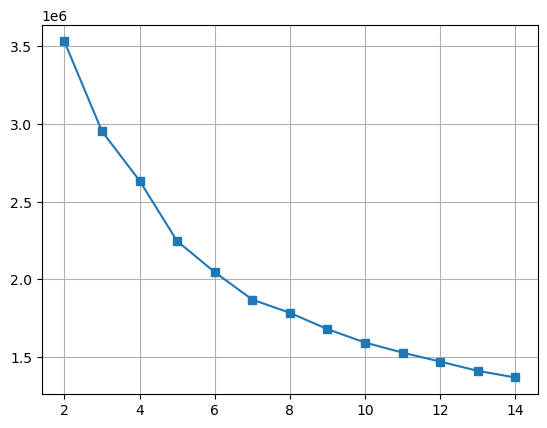

In [239]:
plt.plot(np.arange(2, N), inertia, marker = 's')
plt.grid()
plt.show()

##### Посмотрим метод силуэт. Сначала выделим только числовые признаки

In [240]:
df_clust_num = df_clust[num_col] 

In [241]:
silhoutte = []
N = 15

for i in range(2, N):
    kprototypes = KPrototypes(n_clusters = i, init = 'Huang', verbose = 2)
    preds = kprototypes.fit_predict(df_clust.values, categorical = categ_idx)
#     distance_matrix = pairwise_distances(df_clustering_num, metric = 'hamming')
    silhoutte.append(silhouette_score(df_clust_num, preds))#, metric = 'precomputed'))

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 87048, ncost: 3808194.1707139234
Run: 1, iteration: 2/100, moves: 91443, ncost: 3725477.126546118
Run: 1, iteration: 3/100, moves: 87000, ncost: 3674671.075930937
Run: 1, iteration: 4/100, moves: 56943, ncost: 3649066.1602644115
Run: 1, iteration: 5/100, moves: 32471, ncost: 3640484.609419228
Run: 1, iteration: 6/100, moves: 23257, ncost: 3634203.499287909
Run: 1, iteration: 7/100, moves: 17319, ncost: 3629814.732277882
Run: 1, iteration: 8/100, moves: 9800, ncost: 3628232.5802447028
Run: 1, iteration: 9/100, moves: 3605, ncost: 3627996.5306813424
Run: 1, iteration: 10/100, moves: 1330, ncost: 3627964.265251468
Run: 1, iteration: 11/100, moves: 467, ncost: 3627960.1131288176
Run: 1, iteration: 12/100, moves: 151, ncost: 3627959.7193110045
Run: 1, iteration: 13/100, moves: 55, ncost: 3627959.661576806
Run: 1, iteration: 14/100, moves: 23, ncost: 3627959.652336173
Run: 1, iter

Init: initializing clusters
Starting iterations...
Run: 3, iteration: 1/100, moves: 20917, ncost: 3370592.2503574886
Run: 3, iteration: 2/100, moves: 5682, ncost: 3368120.9488257016
Run: 3, iteration: 3/100, moves: 2263, ncost: 3367908.5434948904
Run: 3, iteration: 4/100, moves: 394, ncost: 3367895.4582054624
Run: 3, iteration: 5/100, moves: 484, ncost: 3367884.1051517176
Run: 3, iteration: 6/100, moves: 20, ncost: 3367883.9715093616
Run: 3, iteration: 7/100, moves: 6, ncost: 3367883.920034942
Run: 3, iteration: 8/100, moves: 14, ncost: 3367883.7717669653
Run: 3, iteration: 9/100, moves: 8, ncost: 3367883.719074548
Run: 3, iteration: 10/100, moves: 0, ncost: 3367883.719074548
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 4, iteration: 1/100, moves: 134467, ncost: 3447269.1299879886
Run: 4, iteration: 2/100, moves: 65826, ncost: 3423112.777251191
Run: 4, iteration: 3/100, moves: 48528, ncost: 3387395.423887445
Run: 4, iteration: 4/100, moves: 73521

Run: 8, iteration: 57/100, moves: 3, ncost: 3210666.904233747
Run: 8, iteration: 58/100, moves: 0, ncost: 3210666.904233747
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 9, iteration: 1/100, moves: 88040, ncost: 3148972.505852934
Run: 9, iteration: 2/100, moves: 49600, ncost: 3078808.8956290134
Run: 9, iteration: 3/100, moves: 40231, ncost: 2974395.6897736196
Run: 9, iteration: 4/100, moves: 5009, ncost: 2967735.7617319
Run: 9, iteration: 5/100, moves: 2863, ncost: 2959003.1532949745
Run: 9, iteration: 6/100, moves: 1302, ncost: 2953849.9826780795
Run: 9, iteration: 7/100, moves: 95, ncost: 2953708.8846800835
Run: 9, iteration: 8/100, moves: 3, ncost: 2953708.8807316683
Run: 9, iteration: 9/100, moves: 0, ncost: 2953708.8807316683
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 10, iteration: 1/100, moves: 168108, ncost: 3138274.930249408
Run: 10, iteration: 2/100, moves: 56269, ncost: 3089863.717633823
Run: 10

Run: 6, iteration: 10/100, moves: 748, ncost: 2666407.7871808237
Run: 6, iteration: 11/100, moves: 290, ncost: 2666407.3392649977
Run: 6, iteration: 12/100, moves: 101, ncost: 2666407.27606644
Run: 6, iteration: 13/100, moves: 30, ncost: 2666407.267695071
Run: 6, iteration: 14/100, moves: 0, ncost: 2666407.267695071
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 7, iteration: 1/100, moves: 141204, ncost: 2728855.1400075653
Run: 7, iteration: 2/100, moves: 23805, ncost: 2709646.387274452
Run: 7, iteration: 3/100, moves: 7101, ncost: 2697722.830278484
Run: 7, iteration: 4/100, moves: 9349, ncost: 2679767.9527467443
Run: 7, iteration: 5/100, moves: 10179, ncost: 2677588.2352206674
Run: 7, iteration: 6/100, moves: 6548, ncost: 2677211.6458274233
Run: 7, iteration: 7/100, moves: 4728, ncost: 2676976.2448040918
Run: 7, iteration: 8/100, moves: 4013, ncost: 2676829.566738625
Run: 7, iteration: 9/100, moves: 3447, ncost: 2676711.59710243
Run: 7, iteration:

Run: 3, iteration: 7/100, moves: 1624, ncost: 2289152.583243774
Run: 3, iteration: 8/100, moves: 995, ncost: 2289142.344865949
Run: 3, iteration: 9/100, moves: 1987, ncost: 2289092.539427
Run: 3, iteration: 10/100, moves: 3148, ncost: 2288993.046505322
Run: 3, iteration: 11/100, moves: 1373, ncost: 2288977.042295394
Run: 3, iteration: 12/100, moves: 234, ncost: 2288976.64842106
Run: 3, iteration: 13/100, moves: 30, ncost: 2288976.643054402
Run: 3, iteration: 14/100, moves: 1, ncost: 2288976.6430213065
Run: 3, iteration: 15/100, moves: 0, ncost: 2288976.6430213065
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 4, iteration: 1/100, moves: 202756, ncost: 2610374.1150668836
Run: 4, iteration: 2/100, moves: 97401, ncost: 2532668.2775805704
Run: 4, iteration: 3/100, moves: 54497, ncost: 2508603.8580853255
Run: 4, iteration: 4/100, moves: 26938, ncost: 2489091.3428469645
Run: 4, iteration: 5/100, moves: 23667, ncost: 2479707.0932199624
Run: 4, iteration: 

...

Init: initializing clusters
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 10, iteration: 1/100, moves: 240925, ncost: 1628194.1892838196
Run: 10, iteration: 2/100, moves: 70929, ncost: 1574881.6896025604
Run: 10, iteration: 3/100, moves: 24851, ncost: 1563529.4153677349
Run: 10, iteration: 4/100, moves: 10790, ncost: 1561155.773785379
Run: 10, iteration: 5/100, moves: 9266, ncost: 1559642.3051255865
Run: 10, iteration: 6/100, moves: 7268, ncost: 1558493.0062758366
Run: 10, iteration: 7/100, moves: 8236, ncost: 1557214.300400984
Run: 10, iteration: 8/100, moves: 5793, ncost: 1556214.3685296478
Run: 10, iteration: 9/100, moves: 4119, ncost: 1554347.5560243838
Run: 10, iteration: 10/100, moves: 3515, ncost: 1553265.5174247702
Run: 10, iteration: 11/100, moves: 2959, ncost: 1552416.524723996
Run: 10, iteration: 12/100, moves: 2666, ncost: 1552275.654775383
Run: 10, iteration: 13/100, moves: 2372, ncost: 1552214.9808799347
Run: 10, iteration: 14/100, m

Run: 5, iteration: 10/100, moves: 4602, ncost: 1527402.0506085076
Run: 5, iteration: 11/100, moves: 4861, ncost: 1527011.9122315657
Run: 5, iteration: 12/100, moves: 5979, ncost: 1526612.4992661239
Run: 5, iteration: 13/100, moves: 9408, ncost: 1525519.8227358893
Run: 5, iteration: 14/100, moves: 15468, ncost: 1522151.4606137516
Run: 5, iteration: 15/100, moves: 22626, ncost: 1512749.0219988925
Run: 5, iteration: 16/100, moves: 21229, ncost: 1501601.7514090198
Run: 5, iteration: 17/100, moves: 13483, ncost: 1492631.867091009
Run: 5, iteration: 18/100, moves: 9723, ncost: 1490182.9950668996
Run: 5, iteration: 19/100, moves: 5324, ncost: 1488821.662080225
Run: 5, iteration: 20/100, moves: 3284, ncost: 1487798.8784257506
Run: 5, iteration: 21/100, moves: 2554, ncost: 1486715.7153747343
Run: 5, iteration: 22/100, moves: 1925, ncost: 1485854.7605462717
Run: 5, iteration: 23/100, moves: 2214, ncost: 1484069.9406235176
Run: 5, iteration: 24/100, moves: 1930, ncost: 1483040.2004536092
Run: 5, 

Run: 10, iteration: 5/100, moves: 31579, ncost: 1516846.0086164076
Run: 10, iteration: 6/100, moves: 21058, ncost: 1514237.6397168022
Run: 10, iteration: 7/100, moves: 11826, ncost: 1513490.3494896486
Run: 10, iteration: 8/100, moves: 6608, ncost: 1513257.7776099355
Run: 10, iteration: 9/100, moves: 2924, ncost: 1513177.8413798646
Run: 10, iteration: 10/100, moves: 2265, ncost: 1513117.8411878233
Run: 10, iteration: 11/100, moves: 1525, ncost: 1513004.587497571
Run: 10, iteration: 12/100, moves: 1525, ncost: 1512807.09065173
Run: 10, iteration: 13/100, moves: 2238, ncost: 1512490.5606601576
Run: 10, iteration: 14/100, moves: 2016, ncost: 1512411.6352565128
Run: 10, iteration: 15/100, moves: 1437, ncost: 1512389.7803644207
Run: 10, iteration: 16/100, moves: 1116, ncost: 1512382.5083452608
Run: 10, iteration: 17/100, moves: 923, ncost: 1512377.9341496518
Run: 10, iteration: 18/100, moves: 847, ncost: 1512374.0141237816
Run: 10, iteration: 19/100, moves: 324, ncost: 1512373.2793893712
Run

Run: 4, iteration: 21/100, moves: 22191, ncost: 1427432.8801503493
Run: 4, iteration: 22/100, moves: 5855, ncost: 1425312.2627567847
Run: 4, iteration: 23/100, moves: 4934, ncost: 1424272.5421034913
Run: 4, iteration: 24/100, moves: 4358, ncost: 1422974.055124446
Run: 4, iteration: 25/100, moves: 1824, ncost: 1422329.223762212
Run: 4, iteration: 26/100, moves: 1494, ncost: 1421355.3385810966
Run: 4, iteration: 27/100, moves: 1736, ncost: 1419793.1655161523
Run: 4, iteration: 28/100, moves: 1543, ncost: 1418957.9411131896
Run: 4, iteration: 29/100, moves: 1171, ncost: 1418219.368047244
Run: 4, iteration: 30/100, moves: 743, ncost: 1418127.847549286
Run: 4, iteration: 31/100, moves: 354, ncost: 1418110.4884693467
Run: 4, iteration: 32/100, moves: 132, ncost: 1418108.50322613
Run: 4, iteration: 33/100, moves: 52, ncost: 1418108.1359134566
Run: 4, iteration: 34/100, moves: 9, ncost: 1418108.1257414632
Run: 4, iteration: 35/100, moves: 0, ncost: 1418108.1257414632
Init: initializing centroi

Run: 7, iteration: 43/100, moves: 1, ncost: 1440977.9193309413
Run: 7, iteration: 44/100, moves: 0, ncost: 1440977.9193309413
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 8, iteration: 1/100, moves: 272652, ncost: 1491354.1886393677
Run: 8, iteration: 2/100, moves: 79525, ncost: 1460122.5583045727
Run: 8, iteration: 3/100, moves: 36886, ncost: 1452882.0647887976
Run: 8, iteration: 4/100, moves: 17676, ncost: 1449934.692661185
Run: 8, iteration: 5/100, moves: 8631, ncost: 1448902.035272795
Run: 8, iteration: 6/100, moves: 4295, ncost: 1447595.116824533
Run: 8, iteration: 7/100, moves: 1956, ncost: 1446862.8030427203
Run: 8, iteration: 8/100, moves: 1940, ncost: 1445462.1007574436
Run: 8, iteration: 9/100, moves: 2514, ncost: 1444335.494703454
Run: 8, iteration: 10/100, moves: 1985, ncost: 1443611.310924619
Run: 8, iteration: 11/100, moves: 1102, ncost: 1443283.6871235764
Run: 8, iteration: 12/100, moves: 737, ncost: 1443217.443917099
Run: 8, itera

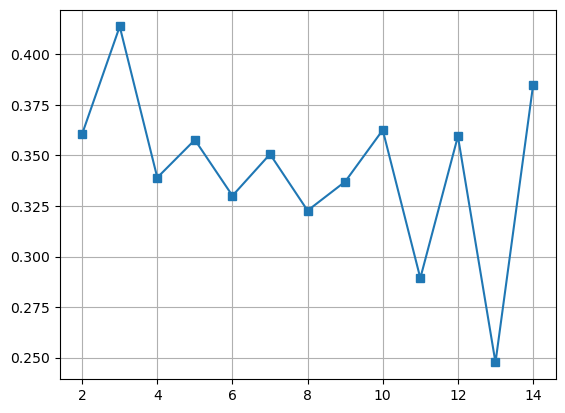

In [242]:
plt.plot(np.arange(2, N), silhoutte, marker = 's')
plt.grid()
plt.show()

###### Разделим на 10 кластеров

In [261]:
kprototypes_K = KPrototypes(n_clusters = 10).fit_predict(df_clustering, categorical = categ_idx)

In [262]:
df_with_clust = df.copy()
df_with_clust['cluster'] = kprototypes_K

In [ ]:
df_with_clust.to_excel('df_with_cluster_KPrototype.xlsx')

In [130]:
df_with_clust = pd.read_excel('df_with_cluster_KPrototype.xlsx', index_col = None).drop('Unnamed: 0', axis = 1)

In [131]:
df_with_clust.head()

,id,gender,age,education,city,country,product,colour,cost,product_sex,base_sale,dt,personal_coef,product_group,color_group,cluster
0,0,0,36,среднее,1201,32,"Велосипед горный женский Stern Mira 2.0 26""",белый/синий,13599,0,1,7,0.5072,Женские товары,Разноцветный,2
1,0,0,36,среднее,1201,32,Стол Outventure,зелёный,1499,5,0,37,0.5072,Другое,Зеленый,0
2,0,0,36,среднее,1201,32,Набор Outventure: стол + 4 стула,бежевый,4799,5,0,37,0.5072,Другое,Коричневый,5
3,4,0,35,среднее,1134,32,Роликовые коньки детские Roces Orlando III,черный/розовый,9199,3,0,0,0.5072,Детские товары,Разноцветный,2
4,4,0,35,среднее,1134,32,Шлем FILA NRK FUN,белый,4999,5,0,0,0.5072,Другое,Светлый,5


###### Посмотрим на средние значения количественных данных в разбивке по кластерам

In [53]:
res_num = df_with_clust.groupby('cluster')[num_col].mean()
res_num['values'] = df_with_clust.groupby('cluster').size().values
res_num

,age,cost,base_sale,personal_coef,values
cluster,,,,,
0,38.565648,1324.403965,0.384799,0.465868,341589
1,37.659244,17124.319453,0.148625,0.449811,30042
2,38.370829,10795.853032,0.249404,0.449926,44867
3,38.303033,6594.509804,0.336312,0.455510,110011
4,36.396958,26028.014697,0.101348,0.447625,15649
5,38.801834,3722.430829,0.404854,0.462309,225674
6,32.659218,326152.798883,0.005587,0.433314,179
7,36.187669,117264.058266,0.048780,0.442539,1476
8,36.780951,43438.149372,0.085975,0.446903,6688


In [54]:
res_num.drop('base_sale', axis =1)

,age,cost,personal_coef,values
cluster,,,,
0,38.565648,1324.403965,0.465868,341589
1,37.659244,17124.319453,0.449811,30042
2,38.370829,10795.853032,0.449926,44867
3,38.303033,6594.509804,0.455510,110011
4,36.396958,26028.014697,0.447625,15649
5,38.801834,3722.430829,0.462309,225674
6,32.659218,326152.798883,0.433314,179
7,36.187669,117264.058266,0.442539,1476
8,36.780951,43438.149372,0.446903,6688


###### Посмотрим на моду категориальных данных в разбивке по кластерам¶

In [55]:
col_cat = df_with_clust.select_dtypes(include = ['object']).columns.tolist()
col_cat.append('gender')
col_cat.append('city')
col_cat.append('product_sex')
col_cat.append('base_sale')

res_cat = df_with_clust.groupby('cluster')[col_cat].agg(lambda x: x.mode().iloc[0])
res_cat['values'] = df_with_clust.groupby('cluster').size().values
res_cat

,education,product,colour,product_group,color_group,gender,city,product_sex,base_sale,values
cluster,,,,,,,,,,
0,среднее,Шорты мужские Demix,черный,Другое,Разноцветный,1,1134,5,0,341589
1,среднее,Кроссовки мужские New Balance 574,черный,Мужские товары,Разноцветный,1,1134,1,0,30042
2,среднее,Тент Outventure Lounge,черный,Мужские товары,Разноцветный,1,1134,1,0,44867
3,среднее,Спортивный костюм женский PUMA Loungewear,черный,Мужские товары,Разноцветный,1,1134,1,0,110011
4,среднее,"Велосипед горный Stern Energy 2.0 27,5""",черный,Другое,Разноцветный,1,1134,5,0,15649
5,среднее,Сабо Crocs Crocband,черный,Мужские товары,Разноцветный,1,1134,1,0,225674
6,среднее,"Велосипед горный Merida One Forty 700 27.5""",зеленый/красный,Другое,Разноцветный,1,1134,5,0,179
7,среднее,Палатка 2-местная Jack Wolfskin Lighthouse II RT,синий,Другое,Разноцветный,1,1134,5,0,1476
8,среднее,"Велосипед горный Stern Force 2.0 29""",черный,Другое,Разноцветный,1,1134,5,0,6688


In [56]:
res_cat.drop(columns = ['product', 'colour'], axis = 1)

,education,product_group,color_group,gender,city,product_sex,base_sale,values
cluster,,,,,,,,
0,среднее,Другое,Разноцветный,1,1134,5,0,341589
1,среднее,Мужские товары,Разноцветный,1,1134,1,0,30042
2,среднее,Мужские товары,Разноцветный,1,1134,1,0,44867
3,среднее,Мужские товары,Разноцветный,1,1134,1,0,110011
4,среднее,Другое,Разноцветный,1,1134,5,0,15649
5,среднее,Мужские товары,Разноцветный,1,1134,1,0,225674
6,среднее,Другое,Разноцветный,1,1134,5,0,179
7,среднее,Другое,Разноцветный,1,1134,5,0,1476
8,среднее,Другое,Разноцветный,1,1134,5,0,6688


In [57]:
print('Доля каждой категории продукта в датафрейме.')
for item in df.product_group.unique().tolist():
#     print(f'{item} - {df[df["product_group"]==item].shape[0]} or {round(df[df["product_group"]==item].shape[0]/df.shape[0]*100, 2)}')
    print(f'{item} - {round(df[df["product_group"]==item].shape[0]/df.shape[0]*100, 2)}%')    

Доля каждой категории продукта в датафрейме.
Женские товары - 25.54%
Другое - 23.95%
Детские товары - 2.33%
Товары для девочек - 3.25%
Товары для мальчиков - 5.41%
Мужские товары - 34.62%
Спортивные товары - 0.97%
Другие товары для спорта и отдыха - 2.58%
Унисекс - 1.34%


In [58]:
print('Доля каждой категории цвета в датафрейме.')
for item in df.color_group.unique().tolist():
#     print(f'{item} - {df[df["color_group"]==item].shape[0]} or {round(df[df["color_group"]==item].shape[0]/df.shape[0]*100, 2)}')
    print(f'{item} - {round(df[df["color_group"]==item].shape[0]/df.shape[0]*100, 2)}%')

Доля каждой категории цвета в датафрейме.
Разноцветный - 28.56%
Зеленый - 4.38%
Коричневый - 6.22%
Светлый - 5.88%
Красный - 3.11%
Другой цвет - 15.38%
Черный - 21.55%
Синий - 6.89%
Серый - 4.81%
Желтый - 1.08%
Бордовый - 0.57%
Фиолетовый - 1.57%


In [59]:
for item in df.education.unique().tolist():
    print(f'{item} - {df[df["education"]==item].shape[0]} or {round(df[df["education"]==item].shape[0]/df.shape[0]*100, 2)}')

среднее - 623993 or 79.99
высшее - 156117 or 20.01


### Модель склонности клиента города 1188 к покупке

In [132]:
# Сформируем датафрейм для построения модели. выберем нужный город и добавим только столбцы, которые повлияют на прогноз
df_with_clust_1188 = df_with_clust[df_with_clust.city == 1188][['id', 'gender', 'age', 'education', 'cost', 'base_sale', 'personal_coef']]

# Для каждого покупателя выведем данные после группировки по id
df_forecast_data = df_with_clust_1188.groupby('id', as_index = False).agg({'gender': 'max', 'age': 'max', 'education': 'max', 
                                                               'cost': 'mean', 'base_sale': lambda x: round(np.mean(x)), 
                                                                      'personal_coef': 'max'})

# Сформируем  количество покупок каждого покупателя
df_forecast_data['id_count'] = df_with_clust_1188[['gender', 'id']].groupby('id', as_index = False).count().gender

# Сформируем таргет: 1 (купит) - при условии, что количество покупок больше или равно медиане и 0 (не купит) - иначе
median_purchases = df_forecast_data.id_count.median()
df_forecast_data['target'] = df_forecast_data['id_count'].apply(lambda x: 1 if x >= median_purchases else 0)

df_forecast_data = df_forecast_data.drop(['id', 'id_count'], axis = 1)
df_forecast_data.head()

,gender,age,education,cost,base_sale,personal_coef,target
0,1,52,среднее,5605.666667,0,0.4304,1
1,1,53,среднее,9124.882353,0,0.4304,1
2,1,21,высшее,5227.571429,1,0.4688,1
3,1,35,высшее,15255.000000,0,0.4688,1
4,1,31,среднее,4905.000000,0,0.4304,1


In [133]:
df_forecast_data_1 = df_forecast_data.copy()

In [134]:
df_forecast_data_1.shape

(12438, 7)

##### Предобработка данных.¶

In [135]:
# Кодировка категориальных известных данных 
x3_ore = ore.fit_transform(df_forecast_data[['education']])
df_forecast_data_1['edu_ore'] = x3_ore

# Сформируем столбцы Х и Y известных данных 
X = df_forecast_data_1.drop(['target', 'education'], axis = 1)
Y = df_forecast_data_1['target']

# Разделим на тренировочные и тестовые данные (для дерева и случайного леса)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

# Нормализация данных
X_sc = sc.fit_transform(X)

# Разделим на тренировочные и тестовые данные (для логистической модели)
X_sc_train, X_sc_test, y_sc_train, y_sc_test = train_test_split(X_sc, Y, test_size = 0.2, random_state = 42)

##### Построим несколько моделей предсказания и выберем лучшую

###### Логистическая модель

In [136]:
lgr = LogisticRegression()
lgr.fit(X_sc_train, y_sc_train)

# Посчитаем прогноз
y_lgr_pred = lgr.predict(X_sc_test)

# Рассчет ошибок
mse_lgr = np.square(mean_squared_error(y_lgr_pred, y_sc_test))
mae_lgr = mean_absolute_error(y_lgr_pred, y_sc_test)
print(f'Обычный прогноз: MSE = {round(mse_lgr, 2)}, MAE = {round(mae_lgr, 2)}')

# Проверим на кросс-валидации
pl = Pipeline([('sc', sc), ('model', lgr)])
y_lgr_pred_cross = cross_val_predict(pl, X_sc_test, y_sc_test)
mse_lgr_cross = np.square(mean_squared_error(y_lgr_pred_cross, y_sc_test))
mae_lgr_cross = mean_absolute_error(y_lgr_pred_cross, y_sc_test)
print(f'Итоги при кросс-валидации: MSE = {round(mse_lgr_cross, 2)}, MAE = {round(mae_lgr_cross, 2)}')

Обычный прогноз: MSE = 0.19, MAE = 0.44
Итоги при кросс-валидации: MSE = 0.2, MAE = 0.45


In [137]:
print("ROC AUC:", roc_auc_score(y_sc_test, y_lgr_pred_cross))
print("Classification Report:\n", classification_report(y_sc_test, y_lgr_pred_cross))
print("Confusion Matrix:\n", confusion_matrix(y_sc_test, y_lgr_pred_cross))

ROC AUC: 0.5211200418687725
Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.19      0.28      1121
           1       0.56      0.85      0.68      1367

    accuracy                           0.55      2488
   macro avg       0.54      0.52      0.48      2488
weighted avg       0.54      0.55      0.50      2488

Confusion Matrix:
 [[ 213  908]
 [ 202 1165]]


###### Модели на основе деревьев¶

In [138]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

# Посчитаем прогноз
y_dtc_pred = dtc.predict(X_test)

# Рассчет ошибок
mse_dtc = np.square(mean_squared_error(y_dtc_pred, y_test))
mae_dtc = mean_absolute_error(y_dtc_pred, y_test)
print(f'Обычный прогноз: MSE = {round(mse_dtc, 2)}, MAE = {round(mae_dtc, 2)}')

# Проверим на кросс-валидации
y_dtc_pred_cross = cross_val_predict(dtc, X_test, y_test)
mse_dtc_cross = np.square(mean_squared_error(y_dtc_pred_cross, y_test))
mae_dtc_cross = mean_absolute_error(y_dtc_pred_cross, y_test)
print(f'Итоги при кросс-валидации: MSE = {round(mse_dtc_cross, 2)}, MAE = {round(mae_dtc_cross, 2)}')

Обычный прогноз: MSE = 0.22, MAE = 0.47
Итоги при кросс-валидации: MSE = 0.21, MAE = 0.45


In [139]:
#Зададим глубину дерева, чтобы не дать ему переобучиться
dtc_dep = DecisionTreeClassifier(max_depth = 5)
dtc_dep.fit(X_train, y_train)

# Проверим на кросс-валидации
y_dtc_dep_pred_cross = cross_val_predict(dtc_dep, X_test, y_test)
mse_dtc_dep_cross = np.square(mean_squared_error(y_dtc_dep_pred_cross, y_test))
mae_dtc_dep_cross = mean_absolute_error(y_dtc_dep_pred_cross, y_test)
print(f'Кросс-валидация при заданной глубине: MSE = {round(mse_dtc_dep_cross, 2)}, MAE = {round(mae_dtc_dep_cross, 2)}')

Кросс-валидация при заданной глубине: MSE = 0.19, MAE = 0.44


In [140]:
print("ROC AUC:", roc_auc_score(y_test, y_dtc_dep_pred_cross))
print("Classification Report:\n", classification_report(y_test, y_dtc_dep_pred_cross))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_dtc_dep_pred_cross))

ROC AUC: 0.5372371700207581
Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.31      0.39      1121
           1       0.57      0.76      0.66      1367

    accuracy                           0.56      2488
   macro avg       0.55      0.54      0.52      2488
weighted avg       0.55      0.56      0.54      2488

Confusion Matrix:
 [[ 350  771]
 [ 325 1042]]


###### Случайный лес

In [141]:
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)

# Посчитаем прогноз на известных данных
y_rfc_pred = rfc.predict(X_test)

# Рассчет ошибок
mse_rfc = np.square(mean_squared_error(y_rfc_pred, y_test))
mae_rfc = mean_absolute_error(y_rfc_pred, y_test)
print(f'Обычный прогноз: MSE = {round(mse_rfc, 2)}, MAE = {round(mae_rfc, 2)}')

# Проверим на кросс-валидации
y_rfc_pred_cross = cross_val_predict(rfc, X_test, y_test)
mse_rfc_cross = np.square(mean_squared_error(y_rfc_pred_cross, y_test))
mae_rfc_cross = mean_absolute_error(y_rfc_pred_cross, y_test)
print(f'Итоги при кросс-валидации: MSE = {round(mse_rfc_cross, 2)}, MAE = {round(mae_rfc_cross, 2)}')

Обычный прогноз: MSE = 0.23, MAE = 0.48
Итоги при кросс-валидации: MSE = 0.21, MAE = 0.46


In [142]:
#Зададим глубину дерева, чтобы не дать ему переобучиться
rfc_dep = RandomForestClassifier(max_depth = 5)
rfc_dep.fit(X_train, y_train)

# Проверим на кросс-валидации
y_rfc_dep_pred_cross = cross_val_predict(rfc_dep, X_test, y_test)
mse_rfc_dep_cross = np.square(mean_squared_error(y_rfc_dep_pred_cross, y_test))
mae_rfc_dep_cross = mean_absolute_error(y_rfc_dep_pred_cross, y_test)
print(f'Кросс-валидация при заданной глубине: MSE = {round(mse_rfc_dep_cross, 2)}, MAE = {round(mae_rfc_dep_cross, 2)}')

Кросс-валидация при заданной глубине: MSE = 0.19, MAE = 0.44


In [143]:
y_proba = rfc_dep.predict_proba(X_test)[:, 1]

print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Classification Report:\n", classification_report(y_test, y_rfc_dep_pred_cross))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_rfc_dep_pred_cross))

ROC AUC: 0.596390841336538
Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.21      0.31      1121
           1       0.57      0.85      0.68      1367

    accuracy                           0.56      2488
   macro avg       0.55      0.53      0.49      2488
weighted avg       0.55      0.56      0.51      2488

Confusion Matrix:
 [[ 239  882]
 [ 206 1161]]


In [144]:
scores = cross_val_score(rfc_dep, X, Y, cv=5, scoring='roc_auc')
print("ROC AUC по фолдам:", scores)
print("Среднее значение ROC AUC:", scores.mean())

ROC AUC по фолдам: [0.58611921 0.59392609 0.58116848 0.58881826 0.60304469]
Среднее значение ROC AUC: 0.5906153450591222


In [145]:
display(Markdown("**Логистическая модель**"))
print(f'Обычный прогноз: MSE = {round(mse_lgr, 2)}, MAE = {round(mae_lgr, 2)}')
print(f'Итоги при кросс-валидации: MSE = {round(mse_lgr_cross, 2)}, MAE = {round(mae_lgr_cross, 2)}')
print(f'ROC AUC: {roc_auc_score(y_sc_test, y_lgr_pred_cross)}')
print(f'Classification Report:\n {classification_report(y_sc_test, y_lgr_pred_cross)}')
print(f'Confusion Matrix:\n {confusion_matrix(y_sc_test, y_lgr_pred_cross)}\n')

display(Markdown("**Модель на основе деревьев**"))
print(f'Обычный прогноз: MSE = {round(mse_dtc, 2)}, MAE = {round(mae_dtc, 2)}')
print(f'Итоги при кросс-валидации: MSE = {round(mse_dtc_cross, 2)}, MAE = {round(mae_dtc_cross, 2)}')
print(f'Кросс-валидация при заданной глубине: MSE = {round(mse_dtc_dep_cross, 2)}, MAE = {round(mae_dtc_dep_cross, 2)}')
print(f'ROC AUC: {roc_auc_score(y_test, y_dtc_dep_pred_cross)}')
print(f'Classification Report:\n {classification_report(y_test, y_dtc_dep_pred_cross)}')
print(f'Confusion Matrix:\n {confusion_matrix(y_test, y_dtc_dep_pred_cross)}\n')

display(Markdown("**Случайный лес**"))
print(f'Обычный прогноз: MSE = {round(mse_rfc, 2)}, MAE = {round(mae_rfc, 2)}')
print(f'Итоги при кросс-валидации: MSE = {round(mse_rfc_cross, 2)}, MAE = {round(mae_rfc_cross, 2)}')
print(f'Кросс-валидация при заданной глубине: MSE = {round(mse_rfc_dep_cross, 2)}, MAE = {round(mae_rfc_dep_cross, 2)}')
print(f'ROC AUC: {roc_auc_score(y_test, y_proba)}')
print(f'Classification Report:\n {classification_report(y_test, y_rfc_dep_pred_cross)}')
print(f'Confusion Matrix:\n {confusion_matrix(y_test, y_rfc_dep_pred_cross)}')

**Логистическая модель**

Обычный прогноз: MSE = 0.19, MAE = 0.44
Итоги при кросс-валидации: MSE = 0.2, MAE = 0.45
ROC AUC: 0.5211200418687725
Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.19      0.28      1121
           1       0.56      0.85      0.68      1367

    accuracy                           0.55      2488
   macro avg       0.54      0.52      0.48      2488
weighted avg       0.54      0.55      0.50      2488

Confusion Matrix:
 [[ 213  908]
 [ 202 1165]]



**Модель на основе деревьев**

Обычный прогноз: MSE = 0.22, MAE = 0.47
Итоги при кросс-валидации: MSE = 0.21, MAE = 0.45
Кросс-валидация при заданной глубине: MSE = 0.19, MAE = 0.44
ROC AUC: 0.5372371700207581
Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.31      0.39      1121
           1       0.57      0.76      0.66      1367

    accuracy                           0.56      2488
   macro avg       0.55      0.54      0.52      2488
weighted avg       0.55      0.56      0.54      2488

Confusion Matrix:
 [[ 350  771]
 [ 325 1042]]



**Случайный лес**

Обычный прогноз: MSE = 0.23, MAE = 0.48
Итоги при кросс-валидации: MSE = 0.21, MAE = 0.46
Кросс-валидация при заданной глубине: MSE = 0.19, MAE = 0.44
ROC AUC: 0.596390841336538
Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.21      0.31      1121
           1       0.57      0.85      0.68      1367

    accuracy                           0.56      2488
   macro avg       0.55      0.53      0.49      2488
weighted avg       0.55      0.56      0.51      2488

Confusion Matrix:
 [[ 239  882]
 [ 206 1161]]


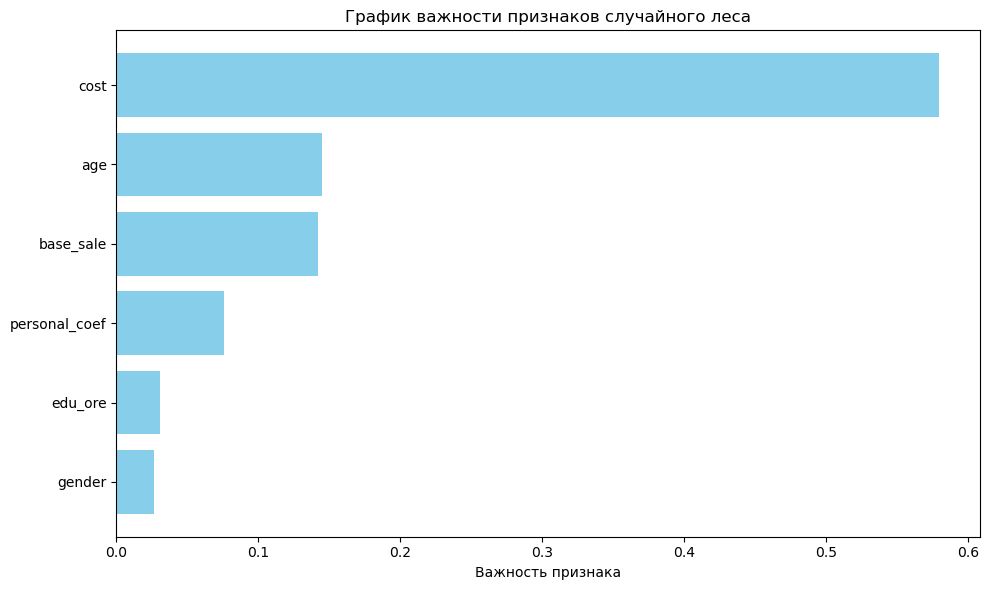

In [146]:
# Получение важности признаков
importances = rfc_dep.feature_importances_
feature_names = X.columns

# Создание DataFrame для удобства
feat_df = pd.DataFrame({'Признак': feature_names, 'Важность': importances})
feat_df = feat_df.sort_values(by='Важность', ascending=True)

# Построение графика
plt.figure(figsize=(10, 6))
plt.barh(feat_df['Признак'], feat_df['Важность'], color='skyblue')
plt.xlabel('Важность признака')
plt.title('График важности признаков случайного леса')
plt.tight_layout()
plt.show()

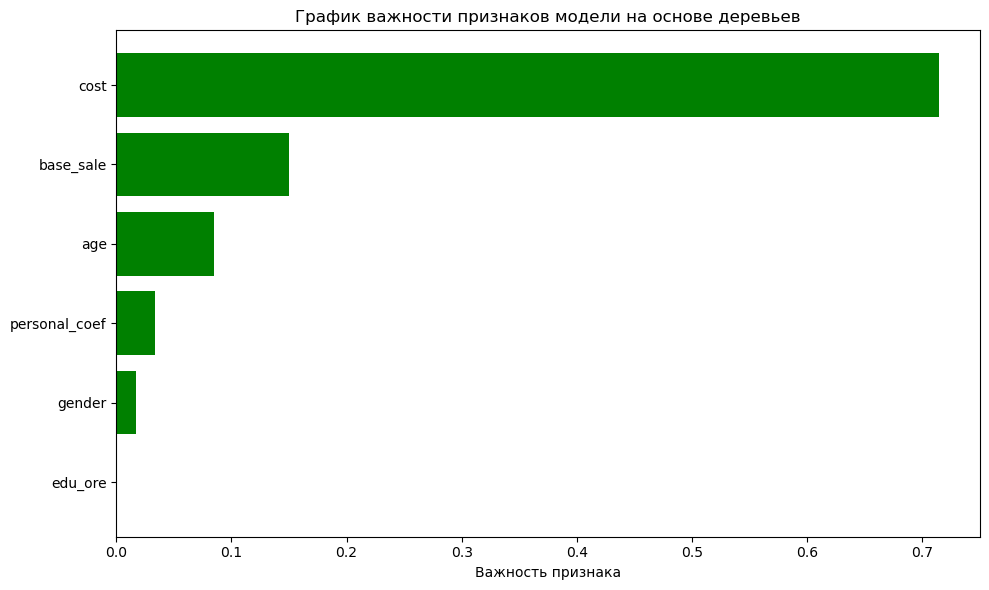

In [148]:
# Получение важности признаков
importances1 = dtc_dep.feature_importances_
feature_names1 = X.columns

# Создание DataFrame для удобства
feat_df1 = pd.DataFrame({'Признак': feature_names1, 'Важность': importances1})
feat_df1 = feat_df1.sort_values(by='Важность', ascending=True)

# Построение графика
plt.figure(figsize=(10, 6))
plt.barh(feat_df1['Признак'], feat_df1['Важность'], color='green')
plt.xlabel('Важность признака')
plt.title('График важности признаков модели на основе деревьев')
plt.tight_layout()
plt.show()